In [40]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import joblib
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# LOAD DATASET

df = pd.read_csv("outputs/hr_attrition_cost_model.csv")

# Check data
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TenureBand,SalaryBand,tenure_risk_score,overtime_flag,salary_gap,manager_tenure_ratio,RecruitmentCost,TrainingCost,ProductivityLoss,TotalAttritionCost
0,41,1,2,1102,2,1,2,1,1,1,...,3,1,0,1,-238.0,0.714286,5993,11986,8989.5,26968.5
1,49,0,1,279,1,8,1,1,1,2,...,3,1,0,0,2242.5,0.636364,5130,10260,7695.0,23085.0
2,37,1,2,1373,1,2,2,4,1,4,...,4,3,1,1,-796.0,0.000000,2090,4180,3135.0,9405.0
3,33,0,1,1392,1,3,4,1,1,5,...,3,3,0,1,21.5,0.000000,2909,5818,4363.5,13090.5
4,27,0,2,591,1,2,1,3,1,7,...,0,1,0,0,582.0,0.666667,3468,6936,5202.0,15606.0


In [42]:
# LOAD TRAINED MODEL

model = joblib.load(r'models\best_attrition_model.pkl')

print("Model Loaded Successfully")

Model Loaded Successfully


In [43]:
# ENCODE CATEGORICAL VARIABLES

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [44]:
# CREATE FEATURES

# Remove target column
X = df.drop('Attrition', axis=1)

# Remove extra cost columns
X = X.drop([
    'RecruitmentCost',
    'TrainingCost',
    'ProductivityLoss',
    'TotalAttritionCost'
], axis=1)

# Check columns
print(X.columns)

Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'TenureBand', 'SalaryBand', 'tenure_risk_score',
       'overtime_flag', 'salary_gap', 'manager_tenure_ratio'],
      dtype='str')


In [45]:
# PREDICT ATTRITION PROBABILITY

# Predict probability
df['Attrition_Probability'] = model.predict_proba(X)[:,1]

# Check results
print(df[['Attrition_Probability']].head())

   Attrition_Probability
0               0.599388
1               0.144241
2               0.535937
3               0.438933
4               0.904374


In [46]:
# CREATE RISK LEVEL

conditions = [
    df['Attrition_Probability'] >= 0.70,
    df['Attrition_Probability'] >= 0.40
]

choices = [
    'High Risk',
    'Medium Risk'
]

df['Risk_Level'] = np.select(
    conditions,
    choices,
    default='Low Risk'
)

print(df[['Attrition_Probability',
          'Risk_Level']].head())

   Attrition_Probability   Risk_Level
0               0.599388  Medium Risk
1               0.144241     Low Risk
2               0.535937  Medium Risk
3               0.438933  Medium Risk
4               0.904374    High Risk


In [47]:
# TOP 50 AT-RISK EMPLOYEES

top_50_risk = df.sort_values(
    by='Attrition_Probability',
    ascending=False
).head(50)

# View
print(top_50_risk[
    ['EmployeeNumber',
     'Department',
     'JobRole',
     'Attrition_Probability',
     'Risk_Level']
])


      EmployeeNumber  Department  JobRole  Attrition_Probability Risk_Level
525              720           2        7               0.953772  High Risk
748             1037           2        7               0.948394  High Risk
695              970           2        7               0.947793  High Risk
1271            1780           2        8               0.936286  High Risk
798             1108           1        6               0.934384  High Risk
688              959           2        8               0.933769  High Risk
1326            1862           2        7               0.932719  High Risk
385              514           1        6               0.931076  High Risk
1021            1439           2        8               0.925684  High Risk
762             1053           1        6               0.920685  High Risk
892             1248           1        6               0.915428  High Risk
618              854           1        6               0.915291  High Risk
1162        

In [48]:
# SAVE TOP 50 EMPLOYEES

os.makedirs("outputs", exist_ok=True)

top_50_risk.to_csv(
    "outputs/top_50_at_risk_employees.csv",
    index=False
)

print("Top 50 Employee List Saved")

Top 50 Employee List Saved


In [49]:
# MONTHLY PREDICTED LEAVERS

# Assume annual attrition spread across 12 months

monthly_leavers = (
    df['Attrition_Probability'].sum()
) / 12

print("Expected Monthly Leavers:")
print(round(monthly_leavers))

Expected Monthly Leavers:
50


In [50]:
# WORKFORCE FORECAST WITH HIRING

# Current employees
current_headcount = len(df)

# Annual attrition rate
annual_attrition_rate = (
    df['Attrition_Probability'].mean()
)

# Monthly attrition rate
monthly_attrition_rate = (
    annual_attrition_rate / 12
)

# Hiring replacement rate
# Example: company replaces 60% leavers
replacement_rate = 0.60

# Forecast months
months = list(range(1,13))

# Store results
forecast = []

# Starting headcount
headcount = current_headcount

# Forecast loop
for month in months:

    # Employees expected to leave
    monthly_leavers = (
        headcount * monthly_attrition_rate
    )

    # Employees hired
    hires = (
        monthly_leavers * replacement_rate
    )

    # Updated headcount
    headcount = (
        headcount
        - monthly_leavers
        + hires
    )

    # Save results
    forecast.append({

        'Month': month,

        'Projected_Headcount': round(headcount),

        'Expected_Leavers': round(monthly_leavers),

        'Expected_Hires': round(hires)

    })

# Convert to dataframe
forecast_df = pd.DataFrame(forecast)

# View results
print(forecast_df)

    Month  Projected_Headcount  Expected_Leavers  Expected_Hires
0       1                 1450                50              30
1       2                 1430                50              30
2       3                 1410                49              29
3       4                 1391                48              29
4       5                 1372                48              29
5       6                 1353                47              28
6       7                 1334                46              28
7       8                 1316                46              27
8       9                 1298                45              27
9      10                 1280                45              27
10     11                 1263                44              26
11     12                 1245                43              26


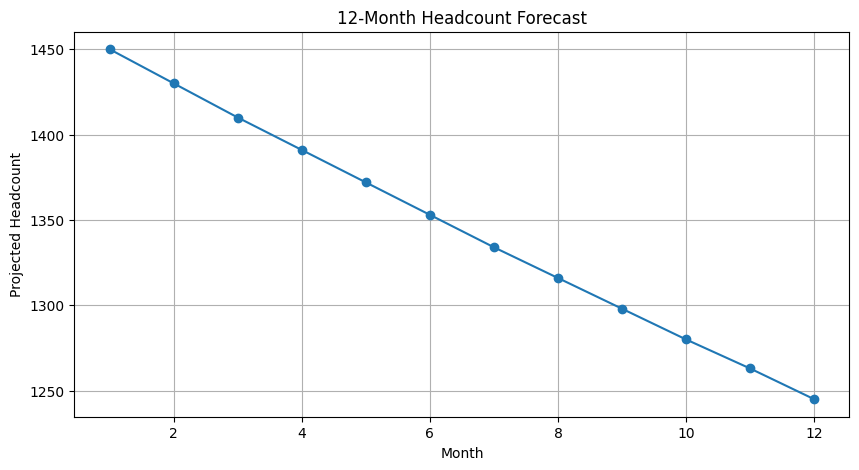

In [51]:
# HEADCOUNT FORECAST CHART

plt.figure(figsize=(10,5))

plt.plot(
    forecast_df['Month'],
    forecast_df['Projected_Headcount'],
    marker='o'
)

plt.title("12-Month Headcount Forecast")

plt.xlabel("Month")

plt.ylabel("Projected Headcount")

plt.grid(True)

plt.show()

In [52]:
# GAP ANALYSIS

minimum_headcount = 1200

forecast_df['Gap'] = (
    forecast_df['Projected_Headcount']
    - minimum_headcount
)

print(forecast_df)

    Month  Projected_Headcount  Expected_Leavers  Expected_Hires  Gap
0       1                 1450                50              30  250
1       2                 1430                50              30  230
2       3                 1410                49              29  210
3       4                 1391                48              29  191
4       5                 1372                48              29  172
5       6                 1353                47              28  153
6       7                 1334                46              28  134
7       8                 1316                46              27  116
8       9                 1298                45              27   98
9      10                 1280                45              27   80
10     11                 1263                44              26   63
11     12                 1245                43              26   45


In [53]:
# HIRING RECOMMENDATION

forecast_df['Hiring_Required'] = np.where(

    forecast_df['Projected_Headcount']
    < minimum_headcount,

    minimum_headcount
    - forecast_df['Projected_Headcount'],

    0
)

print(forecast_df)

    Month  Projected_Headcount  Expected_Leavers  Expected_Hires  Gap  \
0       1                 1450                50              30  250   
1       2                 1430                50              30  230   
2       3                 1410                49              29  210   
3       4                 1391                48              29  191   
4       5                 1372                48              29  172   
5       6                 1353                47              28  153   
6       7                 1334                46              28  134   
7       8                 1316                46              27  116   
8       9                 1298                45              27   98   
9      10                 1280                45              27   80   
10     11                 1263                44              26   63   
11     12                 1245                43              26   45   

    Hiring_Required  
0                 0  
1     

In [54]:
# DEPARTMENT RISK ANALYSIS

dept_risk = df.groupby(
    'Department'
)['Attrition_Probability'].mean()

print(dept_risk)

Department
0    0.404870
1    0.397673
2    0.444264
Name: Attrition_Probability, dtype: float64


In [55]:
# EXPORT POWER BI FILES

# Forecast data
forecast_df.to_csv(
    "outputs/headcount_forecast.csv",
    index=False
)

# Full employee risk data
df.to_csv(
    "outputs/final_employee_risk_data.csv",
    index=False
)

print("Power BI Files Exported")

Power BI Files Exported
